In [1]:
# ==============================================================================
# TASK 4: DATA SCIENCE TOOL MASTERY PROJECT
# Candidate: Pradeep Singh
# Dataset: Zomato Bangalore Restaurants
# Tools: Python, Pandas, NumPy, Matplotlib, Seaborn
# ==============================================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Visual settings
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [4]:
# ------------------------------------------------------------------------------
# 1. DATA INGESTION & TYPE PREPROCESSING
# ------------------------------------------------------------------------------
print("Step 1: Ingesting raw Zomato dataset...")
df_raw = pd.read_csv("zomato.csv")

Step 1: Ingesting raw Zomato dataset...


In [5]:
# Extracting relevant analytical features
cols = [
    "name", "online_order", "book_table", "rate", "votes",
    "location", "rest_type", "cuisines", "approx_cost(for two people)", "listed_in(type)"
]
df = df_raw[cols].drop_duplicates().reset_index(drop=True)

In [6]:
# Function to clean rating column
def clean_rating(x):
    if pd.isna(x) or x == "NEW" or x == "-":
        return np.nan
    try:
        return float(str(x).split("/")[0].strip())
    except:
        return np.nan

In [7]:
# Function to clean approx cost
def clean_cost(x):
    if pd.isna(x):
        return np.nan
    try:
        return float(str(x).replace(",", "").strip())
    except:
        return np.nan

df["rating_clean"] = df["rate"].apply(clean_rating)
df["cost_clean"] = df["approx_cost(for two people)"].apply(clean_cost)

In [8]:
# Median imputation
df["rating_clean"] = df["rating_clean"].fillna(df["rating_clean"].median())
df["cost_clean"] = df["cost_clean"].fillna(df["cost_clean"].median())

In [9]:
# Binary conversions
df["online_order_flag"] = df["online_order"].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)
df["book_table_flag"] = df["book_table"].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)

In [10]:
# Drop missing categorical values
df = df.dropna(subset=["location", "rest_type", "cuisines", "listed_in(type)"]).reset_index(drop=True)

print(f"Dataset successfully cleaned. Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Dataset successfully cleaned. Total rows: 34836, Total columns: 14


In [16]:
# ------------------------------------------------------------------------------
# 2. FEATURE ENGINEERING & SEGMENTATION
# ------------------------------------------------------------------------------
# Feature 1: Number of cuisines offered
df["cuisine_count"] = df["cuisines"].apply(lambda x: len(str(x).split(",")))

# Feature 2: Price tier segmentation
def assign_price_tier(cost):
    if cost <= 400:
        return "Budget (Under Rs 400)"
    elif cost <= 800:
        return "Mid-Range (Rs 401 to 800)"
    else:
        return "Premium (Above Rs 800)"

df["price_tier"] = df["cost_clean"].apply(assign_price_tier)

# Feature 3: Rating category segmentation
def assign_rating_tier(rate):
    if rate >= 4.0:
        return "High Rated (4.0 to 5.0)"
    elif rate >= 3.5:
        return "Average (3.5 to 3.9)"
    else:
        return "Low Rated (Below 3.5)"

df["rating_tier"] = df["rating_clean"].apply(assign_rating_tier)

print("\n=== Sample Processed Data with New Features ===")
print(df[["name", "cost_clean", "price_tier", "rating_clean", "rating_tier", "cuisine_count"]].head(3))


=== Sample Processed Data with New Features ===
              name  cost_clean                 price_tier  rating_clean  \
0            Jalsa       800.0  Mid-Range (Rs 401 to 800)           4.1   
1   Spice Elephant       800.0  Mid-Range (Rs 401 to 800)           4.1   
2  San Churro Cafe       800.0  Mid-Range (Rs 401 to 800)           3.8   

               rating_tier  cuisine_count  
0  High Rated (4.0 to 5.0)              3  
1  High Rated (4.0 to 5.0)              3  
2     Average (3.5 to 3.9)              3  


In [15]:
# ------------------------------------------------------------------------------
# 3. ADVANCED PANDAS TRANSFORMATIONS & GROUP AGGREGATIONS
# ------------------------------------------------------------------------------
# Segment performance matrix
tier_summary = df.groupby("price_tier").agg(
    Outlet_Count=("name", "count"),
    Avg_Rating=("rating_clean", "mean"),
    Avg_Cost=("cost_clean", "mean"),
    Total_Votes=("votes", "sum"),
    Online_Delivery_Pct=("online_order_flag", lambda x: round(x.mean() * 100, 2))
).reset_index()

print("\n=== Price Tier Performance Matrix ===")
print(tier_summary.to_string(index=False))

# Pivot table: Service Type vs Price Tier
service_pivot = pd.pivot_table(
    df,
    values="rating_clean",
    index="listed_in(type)",
    columns="price_tier",
    aggfunc="mean"
).round(2)

print("\n=== Average Rating Pivot Table (Dining Type vs Price Tier) ===")
print(service_pivot)


=== Price Tier Performance Matrix ===
               price_tier  Outlet_Count  Avg_Rating    Avg_Cost  Total_Votes  Online_Delivery_Pct
    Budget (Under Rs 400)         16785    3.637700  288.210188      1301565                57.85
Mid-Range (Rs 401 to 800)         11746    3.712268  604.612549      4050786                68.93
   Premium (Above Rs 800)          6305    4.076431 1385.273592      7323600                46.23

=== Average Rating Pivot Table (Dining Type vs Price Tier) ===
price_tier          Budget (Under Rs 400)  Mid-Range (Rs 401 to 800)  \
listed_in(type)                                                        
Buffet                               3.82                       3.79   
Cafes                                3.72                       3.91   
Delivery                             3.64                       3.69   
Desserts                             3.74                       3.88   
Dine-out                             3.60                       3.68   
D

In [17]:
# ------------------------------------------------------------------------------
# 4. STATISTICAL CORRELATION MATRIX
# ------------------------------------------------------------------------------
numeric_features = ["rating_clean", "cost_clean", "votes", "online_order_flag", "book_table_flag", "cuisine_count"]
corr_matrix = df[numeric_features].corr().round(2)

print("\n=== Numerical Feature Correlation Matrix ===")
print(corr_matrix)


=== Numerical Feature Correlation Matrix ===
                   rating_clean  cost_clean  votes  online_order_flag  \
rating_clean               1.00        0.38   0.43               0.04   
cost_clean                 0.38        1.00   0.39              -0.10   
votes                      0.43        0.39   1.00               0.02   
online_order_flag          0.04       -0.10   0.02               1.00   
book_table_flag            0.43        0.63   0.40              -0.02   
cuisine_count              0.20        0.27   0.24               0.11   

                   book_table_flag  cuisine_count  
rating_clean                  0.43           0.20  
cost_clean                    0.63           0.27  
votes                         0.40           0.24  
online_order_flag            -0.02           0.11  
book_table_flag               1.00           0.28  
cuisine_count                 0.28           1.00  


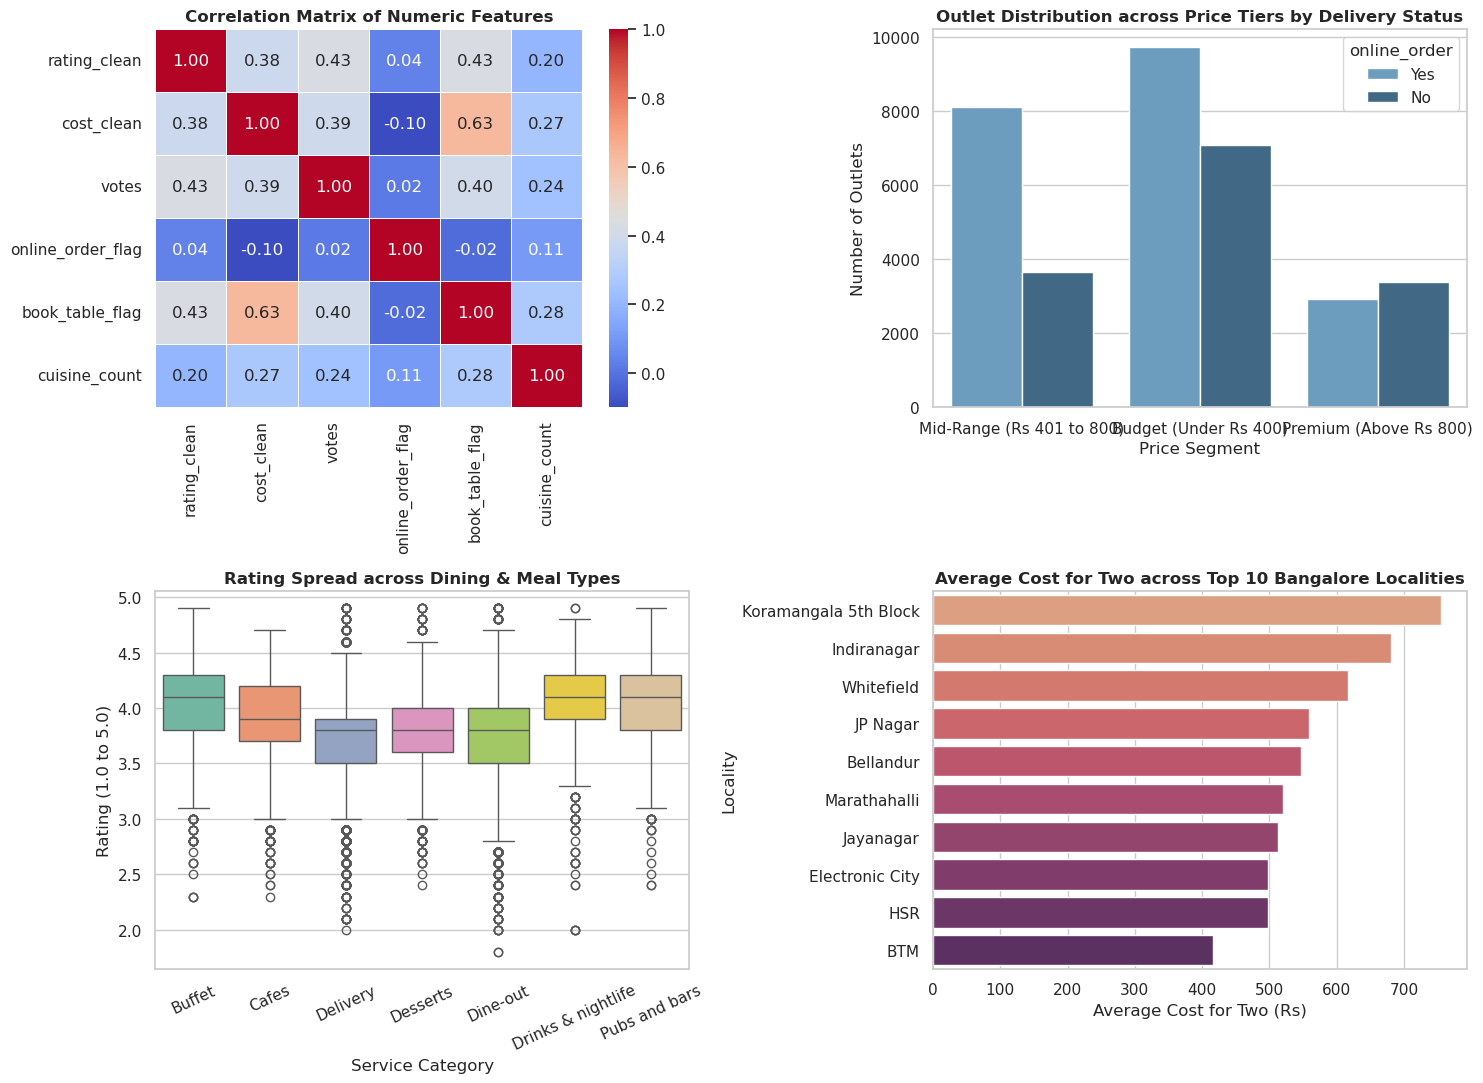

Plots generated and saved successfully as 'tool_mastery_visualizations.png'.


In [18]:
# ------------------------------------------------------------------------------
# 5. MULTI-PANEL TOOL MASTERY DASHBOARD
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 5.1 Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Correlation Matrix of Numeric Features", fontsize=12, fontweight="bold")

# 5.2 Outlets Count by Price Tier
sns.countplot(data=df, x="price_tier", hue="online_order", ax=axes[0, 1], palette="Blues_d")
axes[0, 1].set_title("Outlet Distribution across Price Tiers by Delivery Status", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Price Segment")
axes[0, 1].set_ylabel("Number of Outlets")

# 5.3 Rating Distribution across Meal/Service Types
sns.boxplot(data=df, x="listed_in(type)", y="rating_clean", hue="listed_in(type)", legend=False, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Rating Spread across Dining & Meal Types", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Service Category")
axes[1, 0].set_ylabel("Rating (1.0 to 5.0)")
axes[1, 0].tick_params(axis="x", rotation=25)

# 5.4 Average Cost by Top 10 Localities
top_10_locs = df["location"].value_counts().head(10).index
loc_cost = df[df["location"].isin(top_10_locs)].groupby("location")["cost_clean"].mean().reset_index().sort_values(by="cost_clean", ascending=False)
sns.barplot(data=loc_cost, x="cost_clean", y="location", hue="location", legend=False, ax=axes[1, 1], palette="flare")
axes[1, 1].set_title("Average Cost for Two across Top 10 Bangalore Localities", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Average Cost for Two (Rs)")
axes[1, 1].set_ylabel("Locality")

plt.tight_layout()
plt.savefig("tool_mastery_visualizations.png", dpi=300)
plt.show()
print("Plots generated and saved successfully as 'tool_mastery_visualizations.png'.")